# Federated Learning - Kronolojik Eğitim

## Yapı
- **3 client** (User 1, 2, 3), her biri kendi telefonundaki verileri tutuyor
- **6 round**, her round'da 5 günlük veri penceresi (30 gün / 6 = 5 gün)
- Her round: Global model dağıtılır → Client'lar local eğitim yapar → FedAvg ile aggregate

## Parametreler
| Parametre | Değer |
|-----------|-------|
| Round | 6 |
| Veri/round | 5 gün (~350 kayıt/client) |
| Local epochs | 20 |
| Batch size | 32 |
| Learning rate | 0.01 |
| Aggregation | FedAvg (eşit ağırlıklı ortalama) |

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
import math
import os
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


## 1. Veri Yükleme ve Kronolojik Pencereler

30 günü 6 pencereye bölüyoruz. Her pencere 5 gün.

In [2]:
APP_TO_IDX = {
    "com.instagram.android": 0,
    "com.google.android.youtube": 1,
    "com.linkedin.android": 2,
    "com.whatsapp": 3
}
IDX_TO_LABEL = {0: "Instagram", 1: "YouTube", 2: "LinkedIn", 3: "WhatsApp"}
LOCAL_TZ = "Europe/Istanbul"
NUM_ROUNDS = 6
DAYS_PER_ROUND = 5

USER_FILES = {
    "user1": "app_usage_data_user1.csv",
    "user2": "app_usage_data_user2.csv",
    "user3": "app_usage_data_user3.csv"
}

def load_full_data(csv_path):
    df = pd.read_csv(csv_path)
    df["datetime"] = (
        pd.to_datetime(df["timestamp"], unit="ms", utc=True)
          .dt.tz_convert(LOCAL_TZ)
    )
    df["date"] = df["datetime"].dt.date
    df["hour"] = df["datetime"].dt.hour + df["datetime"].dt.minute / 60.0
    df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["label"] = df["packageName"].map(APP_TO_IDX)
    return df

def split_by_days(df, days_per_round=5):
    """Kronolojik olarak gün bazlı pencerelere böler."""
    all_days = sorted(df["date"].unique())
    windows = []
    for i in range(0, len(all_days), days_per_round):
        window_days = all_days[i:i + days_per_round]
        window_df = df[df["date"].isin(window_days)]
        X = window_df[["sin_hour", "cos_hour"]].values.astype(np.float32)
        y = window_df["label"].values.astype(np.int64)
        windows.append({
            "X": X, "y": y,
            "days": window_days,
            "n_records": len(X)
        })
    return windows

user_windows = {}
for user, path in USER_FILES.items():
    df = load_full_data(path)
    windows = split_by_days(df, DAYS_PER_ROUND)
    user_windows[user] = windows
    print(f"\n{user}: {len(windows)} pencere")
    for i, w in enumerate(windows):
        print(f"  Round {i+1}: Gun {w['days'][0]} -> {w['days'][-1]} ({w['n_records']} kayit)")


user1: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (376 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (374 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (376 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (397 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (365 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (401 kayit)

user2: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (354 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (371 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (351 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (344 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (376 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (332 kayit)

user3: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (371 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (352 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (357 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (365 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (365 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (361 kayit)


## 2. Model + Local Training + FedAvg

In [3]:
class AppUsageModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

    def predict_proba(self, x):
        with torch.no_grad():
            logits = self.forward(x)
            return torch.softmax(logits, dim=1)


def local_train(global_state_dict, X, y, local_epochs=20, batch_size=32, lr=0.01):
    """
    Client tarafinda local egitim.
    Global model weight'lerinden baslar, local veriyle egitir, guncel weight dondurur.
    """
    model = AppUsageModel().to(device)
    model.load_state_dict(copy.deepcopy(global_state_dict))

    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.LongTensor(y).to(device)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

    model.train()
    for epoch in range(local_epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_t).argmax(dim=1)
        acc = (preds == y_t).float().mean().item()

    return model.state_dict(), acc, len(X)


def fed_avg(client_state_dicts, client_sizes):
    """
    FedAvg: Client weight'lerini veri buyuklugune gore agirlikli ortalama ile birlestirir.
    """
    total = sum(client_sizes)
    weights = [s / total for s in client_sizes]

    avg_state = {}
    for key in client_state_dicts[0]:
        avg_state[key] = sum(
            w * client_state_dicts[i][key].float()
            for i, w in enumerate(weights)
        )
    return avg_state


def predict_for_hours(model, hours):
    """24 saat icin tahmin tablosu olusturur."""
    results = []
    model.eval()
    for h in hours:
        sin_h = math.sin(2 * math.pi * h / 24.0)
        cos_h = math.cos(2 * math.pi * h / 24.0)
        x = torch.FloatTensor([[sin_h, cos_h]]).to(device)
        probs = model.predict_proba(x)[0].cpu().numpy()
        pred_idx = probs.argmax()
        results.append({
            "hour": h, "prediction": IDX_TO_LABEL[pred_idx],
            "confidence": probs[pred_idx], "probs": probs
        })
    return results


def print_predictions(results, title=""):
    """Tahmin tablosunu yazdirir."""
    if title:
        print(title)
    print(f" {'saat':>5}  {'tahmin':>9} {'guven':>5}  {'Insta':>6} {'YT':>6} {'Link':>6} {'WA':>6}")
    for r in results:
        p = r["probs"]
        print(f" {r['hour']:02d}:00  {r['prediction']:>9} {r['confidence']*100:4.1f}%  "
              f"{p[0]*100:5.1f}% {p[1]*100:5.1f}% {p[2]*100:5.1f}% {p[3]*100:5.1f}%")


print("Model parametreleri:", sum(p.numel() for p in AppUsageModel().parameters()))

Model parametreleri: 388


## 3. Federated Learning - 6 Round

Her round sonunda global modelin 24-saat predict tablosunu basıyoruz.

In [4]:
global_model = AppUsageModel().to(device)
global_state = global_model.state_dict()

round_history = []

for r in range(NUM_ROUNDS):
    print(f"\n{'#'*70}")
    print(f"  ROUND {r+1}/{NUM_ROUNDS}")
    print(f"{'#'*70}")

    client_states = []
    client_sizes = []

    for user in ["user1", "user2", "user3"]:
        window = user_windows[user][r]
        X, y = window["X"], window["y"]
        days = window["days"]

        state, acc, n = local_train(global_state, X, y, local_epochs=20, batch_size=32, lr=0.01)
        client_states.append(state)
        client_sizes.append(n)

        print(f"  {user}: Gun {days[0]}..{days[-1]} | {n:3d} kayit | Local Acc: {acc*100:.1f}%")

    global_state = fed_avg(client_states, client_sizes)

    global_model.load_state_dict(global_state)
    global_model.eval()

    results = predict_for_hours(global_model, range(24))
    round_history.append({"round": r+1, "results": results, "state": copy.deepcopy(global_state)})

    print(f"\n  --- Global Model (Round {r+1}) Tahminleri ---")
    print_predictions(results)

print(f"\n{'#'*70}")
print(f"  FEDERATED LEARNING TAMAMLANDI")
print(f"{'#'*70}")


######################################################################
  ROUND 1/6
######################################################################


  user1: Gun 2026-01-19..2026-01-23 | 376 kayit | Local Acc: 41.0%


  user2: Gun 2026-01-19..2026-01-23 | 354 kayit | Local Acc: 43.5%


  user3: Gun 2026-01-19..2026-01-23 | 371 kayit | Local Acc: 57.4%

  --- Global Model (Round 1) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00    YouTube 40.2%   27.8%  40.2%   4.6%  27.5%
 01:00    YouTube 41.0%   22.0%  41.0%   5.5%  31.5%
 02:00    YouTube 41.8%   17.5%  41.8%   5.8%  34.8%
 03:00    YouTube 42.4%   16.0%  42.4%   5.2%  36.5%
 04:00    YouTube 41.7%   16.5%  41.7%   4.3%  37.5%
 05:00    YouTube 39.6%   19.1%  39.6%   3.5%  37.8%
 06:00   WhatsApp 38.2%   21.5%  37.3%   3.0%  38.2%
 07:00   WhatsApp 37.5%   25.6%  34.2%   2.8%  37.5%
 08:00   WhatsApp 35.9%   30.0%  31.3%   2.8%  35.9%
 09:00   WhatsApp 35.3%   30.9%  29.0%   4.8%  35.3%
 10:00   WhatsApp 32.9%   31.5%  26.3%   9.3%  32.9%
 11:00   WhatsApp 31.4%   26.5%  25.9%  16.1%  31.4%
 12:00   WhatsApp 32.1%   23.2%  22.4%  22.3%  32.1%
 13:00   WhatsApp 33.3%   20.8%  19.1%  26.8%  33.3%
 14:00   WhatsApp 33.2%   18.8%  17.5%  30.4%  33.2%
 15:00   WhatsApp 32.7%   19.4%  17.0%  

  user1: Gun 2026-01-24..2026-01-28 | 374 kayit | Local Acc: 41.7%


...

  user1: Gun 2026-02-08..2026-02-12 | 365 kayit | Local Acc: 43.8%
  user2: Gun 2026-02-08..2026-02-12 | 376 kayit | Local Acc: 49.2%


  user3: Gun 2026-02-08..2026-02-12 | 365 kayit | Local Acc: 61.1%

  --- Global Model (Round 5) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 40.2%   40.2%  23.6%   5.4%  30.8%
 01:00  Instagram 37.2%   37.2%  24.2%   8.0%  30.6%
 02:00  Instagram 34.3%   34.3%  23.6%  11.0%  31.1%
 03:00   WhatsApp 35.0%   27.6%  25.2%  12.3%  35.0%
 04:00   WhatsApp 36.5%   24.2%  24.9%  14.4%  36.5%
 05:00   WhatsApp 36.1%   24.7%  24.1%  15.1%  36.1%
 06:00   WhatsApp 36.1%   30.5%  22.0%  11.4%  36.1%
 07:00   WhatsApp 38.1%   35.0%  20.0%   6.9%  38.1%
 08:00   WhatsApp 45.7%   30.8%  18.9%   4.6%  45.7%
 09:00   WhatsApp 55.3%    8.8%  26.6%   9.3%  55.3%
 10:00   LinkedIn 34.5%   13.6%  22.7%  34.5%  29.2%
 11:00   WhatsApp 28.3%   20.6%  23.3%  27.8%  28.3%
 12:00  Instagram 27.9%   27.9%  20.2%  24.9%  27.0%
 13:00  Instagram 42.4%   42.4%  13.6%  20.4%  23.6%
 14:00   WhatsApp 30.3%   28.2%  12.7%  28.7%  30.3%
 15:00   LinkedIn 40.7%   10.3%  11.5%  

  user1: Gun 2026-02-13..2026-02-17 | 401 kayit | Local Acc: 44.4%


  user2: Gun 2026-02-13..2026-02-17 | 332 kayit | Local Acc: 48.8%


  user3: Gun 2026-02-13..2026-02-17 | 361 kayit | Local Acc: 60.4%

  --- Global Model (Round 6) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 37.3%   37.3%  27.4%   5.5%  29.8%
 01:00  Instagram 44.7%   44.7%  24.5%   6.2%  24.7%
 02:00    YouTube 35.1%   23.8%  35.1%   6.8%  34.3%
 03:00   WhatsApp 38.9%   15.2%  38.0%   8.0%  38.9%
 04:00   WhatsApp 40.1%   12.8%  36.4%  10.6%  40.1%
 05:00   WhatsApp 39.3%   13.7%  35.5%  11.5%  39.3%
 06:00    YouTube 34.8%   22.0%  34.8%   8.6%  34.6%
 07:00  Instagram 40.2%   40.2%  30.5%   3.2%  26.0%
 08:00  Instagram 46.3%   46.3%  25.8%   1.1%  26.8%
 09:00   WhatsApp 41.2%   25.9%  29.9%   3.0%  41.2%
 10:00   LinkedIn 32.1%   26.5%  17.1%  32.1%  24.4%
 11:00   LinkedIn 30.2%   27.6%  17.3%  30.2%  24.8%
 12:00   LinkedIn 32.4%   24.0%  18.3%  32.4%  25.3%
 13:00  Instagram 36.7%   36.7%  17.7%  24.4%  21.3%
 14:00   LinkedIn 31.2%   21.4%  19.7%  31.2%  27.7%
 15:00   LinkedIn 37.0%   10.9%  16.5%  

## 4. Final Global Model - Detaylı Karşılaştırma

Her kullanıcının beklenen pattern'lerine karşı final global modelin tahminleri.

In [5]:
expected_patterns = {
    "user1": "08-10: %100 Instagram | 14-18: LinkedIn+WhatsApp | 18-20: YouTube+Instagram",
    "user2": "08-10: %100 YouTube | 12-14: %100 Instagram | 14-18: LinkedIn+WhatsApp",
    "user3": "08-10: %100 WhatsApp | 18-22: %100 YouTube | 22-02: Instagram"
}

print("="*70)
print("  FINAL GLOBAL MODEL vs BIREYSEL BEKLENTILER")
print("="*70)

final_results = round_history[-1]["results"]

for user, pattern in expected_patterns.items():
    print(f"\n  {user.upper()} beklentisi: {pattern}")

print(f"\n{'='*70}")
print(f"  GLOBAL MODEL - 24 SAAT TAHMIN TABLOSU")
print(f"{'='*70}")
print_predictions(final_results)

print(f"\n{'='*70}")
print("  SABIT ETKI SAATLERI - OZET")
print(f"{'='*70}")

checks = [
    ("08:00-10:00", [8, 9], {
        "user1": "Instagram",
        "user2": "YouTube",
        "user3": "WhatsApp"
    }),
    ("12:00-14:00", [12, 13], {
        "user2": "Instagram"
    }),
    ("18:00-22:00", [18, 19, 20, 21], {
        "user3": "YouTube"
    }),
]

for label, hours, user_expected in checks:
    print(f"\n  {label}:")
    for h in hours:
        r = final_results[h]
        p = r["probs"]
        expected_apps = [f"{u}: {app}" for u, app in user_expected.items()]
        print(f"    {h:02d}:00 -> {r['prediction']} ({r['confidence']*100:.1f}%)  "
              f"[Insta:{p[0]*100:.0f}% YT:{p[1]*100:.0f}% Link:{p[2]*100:.0f}% WA:{p[3]*100:.0f}%]  "
              f"Beklenen: {', '.join(expected_apps)}")

  FINAL GLOBAL MODEL vs BIREYSEL BEKLENTILER

  USER1 beklentisi: 08-10: %100 Instagram | 14-18: LinkedIn+WhatsApp | 18-20: YouTube+Instagram

  USER2 beklentisi: 08-10: %100 YouTube | 12-14: %100 Instagram | 14-18: LinkedIn+WhatsApp

  USER3 beklentisi: 08-10: %100 WhatsApp | 18-22: %100 YouTube | 22-02: Instagram

  GLOBAL MODEL - 24 SAAT TAHMIN TABLOSU
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 37.3%   37.3%  27.4%   5.5%  29.8%
 01:00  Instagram 44.7%   44.7%  24.5%   6.2%  24.7%
 02:00    YouTube 35.1%   23.8%  35.1%   6.8%  34.3%
 03:00   WhatsApp 38.9%   15.2%  38.0%   8.0%  38.9%
 04:00   WhatsApp 40.1%   12.8%  36.4%  10.6%  40.1%
 05:00   WhatsApp 39.3%   13.7%  35.5%  11.5%  39.3%
 06:00    YouTube 34.8%   22.0%  34.8%   8.6%  34.6%
 07:00  Instagram 40.2%   40.2%  30.5%   3.2%  26.0%
 08:00  Instagram 46.3%   46.3%  25.8%   1.1%  26.8%
 09:00   WhatsApp 41.2%   25.9%  29.9%   3.0%  41.2%
 10:00   LinkedIn 32.1%   26.5%  17.1%  32.1%  24.4%
 11:00

## 5. Round Bazlı Evrim - Sabit Saatlerin Değişimi

Her round sonunda kritik saatlerdeki tahminlerin nasıl değiştiğini takip edelim.

In [6]:
critical_hours = {
    9: "08-10 blogu (U1:Insta, U2:YT, U3:WA)",
    13: "12-14 blogu (U2:Insta)",
    20: "18-22 blogu (U3:YT)",
    0: "22-02 blogu (U3:Insta)"
}

print("="*70)
print("  ROUND BAZLI EVRIM - KRITIK SAATLER")
print("="*70)

for hour, desc in critical_hours.items():
    print(f"\n  Saat {hour:02d}:00 - {desc}")
    print(f"  {'Round':>5}  {'Tahmin':>9}  {'Insta':>6} {'YT':>6} {'Link':>6} {'WA':>6}")
    for rh in round_history:
        r = rh["results"][hour]
        p = r["probs"]
        print(f"  R{rh['round']:>4}  {r['prediction']:>9}  "
              f"{p[0]*100:5.1f}% {p[1]*100:5.1f}% {p[2]*100:5.1f}% {p[3]*100:5.1f}%")

  ROUND BAZLI EVRIM - KRITIK SAATLER

  Saat 09:00 - 08-10 blogu (U1:Insta, U2:YT, U3:WA)
  Round     Tahmin   Insta     YT   Link     WA
  R   1   WhatsApp   30.9%  29.0%   4.8%  35.3%
  R   2   WhatsApp   18.1%  32.1%   3.4%  46.3%
  R   3   WhatsApp   22.4%  26.3%   6.0%  45.4%
  R   4   WhatsApp   13.7%  27.8%   4.1%  54.4%
  R   5   WhatsApp    8.8%  26.6%   9.3%  55.3%
  R   6   WhatsApp   25.9%  29.9%   3.0%  41.2%

  Saat 13:00 - 12-14 blogu (U2:Insta)
  Round     Tahmin   Insta     YT   Link     WA
  R   1   WhatsApp   20.8%  19.1%  26.8%  33.3%
  R   2   LinkedIn   16.5%  11.3%  41.0%  31.2%
  R   3  Instagram   31.6%  13.8%  29.7%  24.8%
  R   4  Instagram   39.5%  16.3%  24.3%  19.9%
  R   5  Instagram   42.4%  13.6%  20.4%  23.6%
  R   6  Instagram   36.7%  17.7%  24.4%  21.3%

  Saat 20:00 - 18-22 blogu (U3:YT)
  Round     Tahmin   Insta     YT   Link     WA
  R   1    YouTube   25.1%  47.0%   4.8%  23.1%
  R   2    YouTube   17.4%  61.4%   4.3%  16.9%
  R   3    YouTube 

## 6. Global Model Ağırlıklarını Kaydet

In [7]:
os.makedirs("weights", exist_ok=True)

def save_weights_json(state_dict, filepath):
    serializable = {}
    for key, tensor in state_dict.items():
        serializable[key] = tensor.cpu().tolist()
    with open(filepath, "w") as f:
        json.dump(serializable, f, indent=2)
    print(f"  Kaydedildi: {filepath}")

for rh in round_history:
    save_weights_json(rh["state"], f"weights/global_round{rh['round']}_weights.json")

save_weights_json(round_history[-1]["state"], "weights/global_final_weights.json")

print("\nKaydedilen dosyalar:")
for f in sorted(os.listdir("weights")):
    if f.startswith("global"):
        size_kb = os.path.getsize(f"weights/{f}") / 1024
        print(f"  {f}: {size_kb:.1f} KB")

  Kaydedildi: weights/global_round1_weights.json
  Kaydedildi: weights/global_round2_weights.json
  Kaydedildi: weights/global_round3_weights.json
  Kaydedildi: weights/global_round4_weights.json
  Kaydedildi: weights/global_round5_weights.json
  Kaydedildi: weights/global_round6_weights.json
  Kaydedildi: weights/global_final_weights.json

Kaydedilen dosyalar:
  global_final_weights.json: 11.2 KB
  global_round1_weights.json: 11.3 KB
  global_round2_weights.json: 11.3 KB
  global_round3_weights.json: 11.2 KB
  global_round4_weights.json: 11.3 KB
  global_round5_weights.json: 11.2 KB
  global_round6_weights.json: 11.2 KB


## 7. Training Loss Evrimi

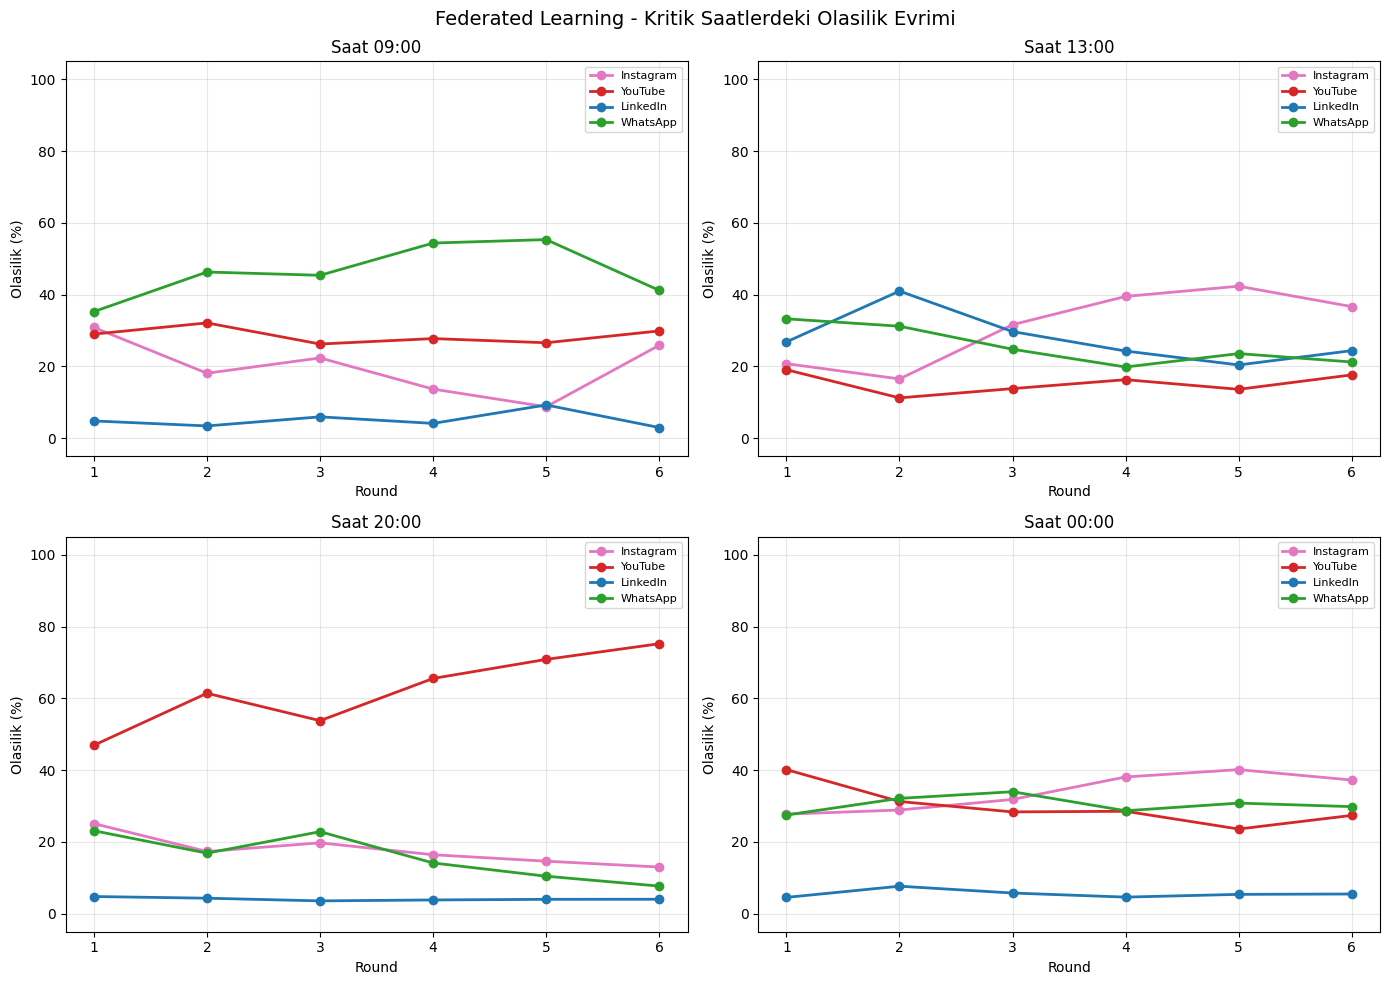

Grafik kaydedildi: fl_evolution.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

critical = {9: ("09:00", axes[0, 0]), 13: ("13:00", axes[0, 1]),
            20: ("20:00", axes[1, 0]), 0: ("00:00", axes[1, 1])}

app_colors = {"Instagram": "tab:pink", "YouTube": "tab:red",
              "LinkedIn": "tab:blue", "WhatsApp": "tab:green"}

for hour, (label, ax) in critical.items():
    rounds = [rh["round"] for rh in round_history]
    for app_idx, app_name in IDX_TO_LABEL.items():
        probs = [rh["results"][hour]["probs"][app_idx] * 100 for rh in round_history]
        ax.plot(rounds, probs, marker="o", label=app_name, color=app_colors[app_name], linewidth=2)
    ax.set_title(f"Saat {label}")
    ax.set_xlabel("Round")
    ax.set_ylabel("Olasilik (%)")
    ax.set_ylim(-5, 105)
    ax.set_xticks(rounds)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Federated Learning - Kritik Saatlerdeki Olasilik Evrimi", fontsize=14)
plt.tight_layout()
plt.savefig("fl_evolution.png", dpi=150)
plt.show()
print("Grafik kaydedildi: fl_evolution.png")

## 8. Machine Unlearning Experiments

Federated Learning sonrası **user1** (Instagram dominant, 08:00-10:00 bloğu) silinecek. İki yöntem karşılaştırılıyor:

| Yöntem | Algoritma | Açıklama |
|--------|-----------|----------|
| **Client-Based** | FedEraser (Liu et al. 2021) | Gradient ascent + recovery rounds |
| **Server-Based** | Yang & Zhao 2024 | Sadece recovery rounds (gradient ascent yok) |

### Aşama 0: Delta History Oluşturma

FL eğitimi yeniden çalıştırılarak her round'da her client'ın delta'ları (`w_after − w_before`) kaydediliyor. `delta_history.pkl` varsa atlanır.

In [9]:

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def analyze_8_to_10_predictions(model, user_name):
    """Gerçek 8-10 saati veri noktalarını filtreleyip ortalama olasılık hesaplar."""
    df          = load_full_data(USER_FILES[user_name])
    df_filtered = df[(df["hour"] >= 8) & (df["hour"] < 10)]
    X = df_filtered[["sin_hour", "cos_hour"]].values.astype(np.float32)

    model.eval()
    X_t = torch.FloatTensor(X).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(X_t), dim=1).cpu().numpy()

    avg_probs = probs.mean(axis=0)
    return {
        "Instagram":    float(avg_probs[0]),
        "YouTube":      float(avg_probs[1]),
        "LinkedIn":     float(avg_probs[2]),
        "WhatsApp":     float(avg_probs[3]),
        "sample_count": int(len(X))
    }


def calculate_entropy(probs_dict):
    """entropy = -sum(p * log(p)).  Yüksek = belirsiz tahmin (unlearning başarılı)."""
    probs = np.array([probs_dict["Instagram"], probs_dict["YouTube"],
                      probs_dict["LinkedIn"],  probs_dict["WhatsApp"]])
    probs = np.clip(probs, 1e-10, 1.0)
    return float(-np.sum(probs * np.log(probs)))


def calculate_accuracy(model, user_name):
    """Bir kullanıcının tüm verisi üzerinde top-1 doğruluk hesaplar."""
    df  = load_full_data(USER_FILES[user_name])
    X   = df[["sin_hour", "cos_hour"]].values.astype(np.float32)
    y   = df["label"].values.astype(np.int64)
    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.LongTensor(y).to(device)
    model.eval()
    with torch.no_grad():
        preds = model(X_t).argmax(dim=1)
        acc   = (preds == y_t).float().mean().item()
    return float(acc)


print("✅ Helper fonksiyonlar tanımlandı: analyze_8_to_10_predictions, calculate_entropy, calculate_accuracy")


✅ Helper fonksiyonlar tanımlandı: analyze_8_to_10_predictions, calculate_entropy, calculate_accuracy


In [10]:

import pickle
import os
import time
import json
from datetime import datetime

print("=" * 60)
print("  AŞAMA 0: DELTA HISTORY OLUŞTURMA")
print("=" * 60)

if os.path.exists("delta_history.pkl"):
    with open("delta_history.pkl", "rb") as f:
        delta_history = pickle.load(f)
    print("✅ delta_history.pkl mevcut, yüklendi")
    for r in sorted(delta_history.keys()):
        print(f"   Round {r}: {list(delta_history[r].keys())}")
else:
    print("delta_history.pkl bulunamadı — FL yeniden çalıştırılıyor (delta ile)...")
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    _g_state     = AppUsageModel().to(device).state_dict()
    delta_history = {}

    for r in range(NUM_ROUNDS):
        delta_history[r] = {}
        _client_states = []
        _client_sizes  = []

        for user in ["user1", "user2", "user3"]:
            window  = user_windows[user][r]
            X, y    = window["X"], window["y"]
            w_before = copy.deepcopy(_g_state)

            state, acc, n = local_train(_g_state, X, y,
                                        local_epochs=20, batch_size=32, lr=0.01)

            delta = {k: state[k].float() - w_before[k].float() for k in w_before}
            delta_history[r][user] = delta

            _client_states.append(state)
            _client_sizes.append(n)

        _g_state = fed_avg(_client_states, _client_sizes)
        print(f"   Round {r}: delta'lar kaydedildi → {list(delta_history[r].keys())}")

    with open("delta_history.pkl", "wb") as f:
        pickle.dump(delta_history, f)
    print("✅ Delta history oluşturuldu ve delta_history.pkl kaydedildi")

os.makedirs("results", exist_ok=True)


  AŞAMA 0: DELTA HISTORY OLUŞTURMA
✅ delta_history.pkl mevcut, yüklendi
   Round 0: ['user1', 'user2', 'user3']
   Round 1: ['user1', 'user2', 'user3']
   Round 2: ['user1', 'user2', 'user3']
   Round 3: ['user1', 'user2', 'user3']
   Round 4: ['user1', 'user2', 'user3']
   Round 5: ['user1', 'user2', 'user3']


## 9. Aşama 1: Client-Based Unlearning (FedEraser)

**Algoritma:** FedEraser (Liu et al. 2021) — Delta-guided Parameter Subtraction

**Gerçek FedEraser adımı:**
1. **Delta subtraction** — Her round'da forget client'ın FedAvg-ağırlıklı delta katkısı (`n_forget/N × delta`) toplanır, global modelden çıkarılır. Bu, client'ın tüm eğitim geçmişini geri alır.
2. **Recovery Rounds** — Düzeltilmiş modelden başlayarak kalan clientlar (user2, user3) ile fine-tuning yapılır.

> **Neden gradient ascent değil?** Adam + negatif gradient kombinasyonu loss'u kontrol edilemez şekilde büyütür (25 → 46705). Delta subtraction aynı amacı (client katkısını geri almak) nümerik olarak kararlı bir şekilde gerçekleştirir.

In [11]:

def client_based_unlearning(
    initial_global_state,
    forget_user,
    remaining_users,
    delta_history,
    recovery_rounds=3,
    recovery_epochs=5,
    delta_scale=1.0
):
    """
    FedEraser (Liu et al. 2021) — Delta-guided parameter subtraction.

    Gerçek FedEraser adımı:
      Her round'da forget client'ın FedAvg-ağırlıklı delta katkısı hesaplanır
      ve global modelden çıkarılır. Bu, client'ın parametrik izini siler.
      Ardından kalan clientlarla recovery rounds yapılır.

    Not: Gradient ascent yerine delta subtraction kullanılıyor çünkü
    Adam + negatif gradient = loss explosion (25→46705).
    """
    start_time = time.time()
    all_users  = [forget_user] + remaining_users

    print("-" * 55)
    print("  AŞAMA 1: CLIENT-BASED UNLEARNING (FedEraser)")
    print("-" * 55)

    # ── Step 1: Delta-guided parameter subtraction ───────────────
    print("\nStep 1: Delta-guided parameter subtraction")
    print(f"  Forget client : {forget_user}")
    print(f"  Rounds        : {NUM_ROUNDS}")
    print(f"  Delta scale   : {delta_scale}")

    # Her round'daki ağırlıklı delta katkısını biriktir
    correction = {k: torch.zeros_like(initial_global_state[k].float())
                  for k in initial_global_state}

    per_round_weights = []
    for r in range(NUM_ROUNDS):
        n_forget  = user_windows[forget_user][r]["n_records"]
        n_total   = sum(user_windows[u][r]["n_records"] for u in all_users)
        w_forget  = n_forget / n_total
        per_round_weights.append(w_forget)

        for k in correction:
            correction[k] = correction[k] + w_forget * delta_history[r][forget_user][k]

        print(f"  Round {r}: n_forget={n_forget}, n_total={n_total}, w={w_forget:.3f}")

    # Global modelden katkıyı çıkar
    corrected_state = {
        k: initial_global_state[k].float() - delta_scale * correction[k]
        for k in initial_global_state
    }

    correction_norm = sum(v.norm().item() for v in correction.values())
    print(f"\n  Toplam correction norm  : {correction_norm:.4f}")
    print(f"  Ort. round weight (u1)  : {sum(per_round_weights)/len(per_round_weights):.3f}")
    print("  ✅ Delta subtraction tamamlandı")

    # ── Step 2: Recovery Rounds ───────────────────────────────────
    print(f"\nStep 2: Recovery Rounds ({recovery_rounds} round, {recovery_epochs} epoch/round)")

    recovery_state        = corrected_state
    recovery_loss_history = []

    for rr in range(recovery_rounds):
        print(f"  Recovery Round {rr+1}/{recovery_rounds}:")
        rec_states   = []
        rec_sizes    = []
        round_losses = []

        for user in remaining_users:
            X_u = np.vstack([user_windows[user][r]["X"] for r in range(NUM_ROUNDS)])
            y_u = np.hstack([user_windows[user][r]["y"] for r in range(NUM_ROUNDS)])
            state, acc, n = local_train(recovery_state, X_u, y_u,
                                        local_epochs=recovery_epochs, batch_size=32, lr=0.01)
            rec_states.append(state)
            rec_sizes.append(n)

            _m = AppUsageModel().to(device)
            _m.load_state_dict(state)
            _m.eval()
            with torch.no_grad():
                out  = _m(torch.FloatTensor(X_u).to(device))
                loss = nn.CrossEntropyLoss()(out, torch.LongTensor(y_u).to(device)).item()
            round_losses.append(loss)
            print(f"    {user}: acc={acc*100:.1f}%, loss={loss:.4f}")

        recovery_state = fed_avg(rec_states, rec_sizes)
        avg_loss       = sum(round_losses) / len(round_losses)
        recovery_loss_history.append(avg_loss)
        print(f"    FedAvg yapıldı | avg loss: {avg_loss:.4f}")

    cb_model   = AppUsageModel().to(device)
    cb_model.load_state_dict(recovery_state)
    total_time = time.time() - start_time
    print(f"  ✅ Tamamlandı ({total_time:.2f}s)")

    return {
        "model"                : cb_model,
        "state"                : recovery_state,
        "correction_norm"      : correction_norm,
        "per_round_weights"    : per_round_weights,
        "recovery_loss_history": recovery_loss_history,
        "ascent_loss_history"  : [],   # gradient ascent kullanılmıyor
        "total_time"           : total_time
    }

# ── RUN ─────────────────────────────────────────────────────────
FORGET_USER     = "user1"
REMAINING_USERS = ["user2", "user3"]

cb_results = client_based_unlearning(
    initial_global_state = global_state,
    forget_user          = FORGET_USER,
    remaining_users      = REMAINING_USERS,
    delta_history        = delta_history,
    recovery_rounds      = 3,
    recovery_epochs      = 5,
    delta_scale          = 1.0
)
cb_model = cb_results["model"]


-------------------------------------------------------
  AŞAMA 1: CLIENT-BASED UNLEARNING (FedEraser)
-------------------------------------------------------

Step 1: Delta-guided parameter subtraction
  Forget client : user1
  Rounds        : 6
  Delta scale   : 1.0
  Round 0: n_forget=376, n_total=1101, w=0.342
  Round 1: n_forget=374, n_total=1097, w=0.341
  Round 2: n_forget=376, n_total=1084, w=0.347
  Round 3: n_forget=397, n_total=1106, w=0.359
  Round 4: n_forget=365, n_total=1106, w=0.330
  Round 5: n_forget=401, n_total=1094, w=0.367

  Toplam correction norm  : 9.1161
  Ort. round weight (u1)  : 0.347
  ✅ Delta subtraction tamamlandı

Step 2: Recovery Rounds (3 round, 5 epoch/round)
  Recovery Round 1/3:


    user2: acc=45.2%, loss=1.1253


    user3: acc=59.2%, loss=0.9155
    FedAvg yapıldı | avg loss: 1.0204
  Recovery Round 2/3:


    user2: acc=44.5%, loss=1.1238


    user3: acc=60.0%, loss=0.9175
    FedAvg yapıldı | avg loss: 1.0207
  Recovery Round 3/3:


    user2: acc=44.3%, loss=1.1397


    user3: acc=59.6%, loss=0.9105
    FedAvg yapıldı | avg loss: 1.0251
  ✅ Tamamlandı (2.12s)


## 10. Aşama 2: Server-Based Unlearning

**Algoritma:** Server-Standalone Unlearning (Yang & Zhao 2024)

Gradient ascent **uygulanmaz**. Orijinal global modelden başlanarak sadece kalan clientlar (user2, user3) ile recovery rounds yapılır. Client katılımı gerektirmez — sunucu tarafında gerçekleşir.

In [12]:

def server_based_unlearning(
    initial_global_state,
    forget_user,
    remaining_users,
    delta_history=None,
    recovery_rounds=2,
    recovery_epochs=5
):
    """
    Server-Based Unlearning (Yang & Zhao 2024).
    Gradient ascent uygulanmaz; orijinal global modelden başlanarak
    sadece kalan clientlarla recovery rounds yapılır.
    """
    start_time = time.time()
    print("-" * 50)
    print("  AŞAMA 2: SERVER-BASED UNLEARNING")
    print("-" * 50)

    if delta_history:
        total_norm = sum(
            v.norm().item()
            for r in range(NUM_ROUNDS)
            if forget_user in delta_history[r]
            for v in delta_history[r][forget_user].values()
        )
        print(f"  Tahmini silinecek client toplam delta norm: {total_norm:.4f}")

    print(f"\nStep 1: Recovery Rounds ({recovery_rounds} round, {recovery_epochs} epoch/round)")

    recovery_state       = copy.deepcopy(initial_global_state)
    recovery_loss_history = []

    for rr in range(recovery_rounds):
        print(f"  Recovery Round {rr+1}/{recovery_rounds}:")
        rec_states   = []
        rec_sizes    = []
        round_losses = []

        for user in remaining_users:
            X_u = np.vstack([user_windows[user][r]["X"] for r in range(NUM_ROUNDS)])
            y_u = np.hstack([user_windows[user][r]["y"] for r in range(NUM_ROUNDS)])
            state, acc, n = local_train(recovery_state, X_u, y_u,
                                        local_epochs=recovery_epochs, batch_size=32, lr=0.01)
            rec_states.append(state)
            rec_sizes.append(n)

            _m = AppUsageModel().to(device)
            _m.load_state_dict(state)
            _m.eval()
            with torch.no_grad():
                out  = _m(torch.FloatTensor(X_u).to(device))
                loss = nn.CrossEntropyLoss()(out, torch.LongTensor(y_u).to(device)).item()
            round_losses.append(loss)
            print(f"    {user} eğitim: acc={acc*100:.1f}%, loss={loss:.4f}")

        recovery_state = fed_avg(rec_states, rec_sizes)
        avg_loss       = sum(round_losses) / len(round_losses)
        recovery_loss_history.append(avg_loss)
        print(f"    FedAvg yapıldı | avg loss: {avg_loss:.4f}")

    sb_model   = AppUsageModel().to(device)
    sb_model.load_state_dict(recovery_state)
    total_time = time.time() - start_time
    print(f"  ✅ Recovery tamamlandı ({total_time:.2f}s)")

    return {
        "model": sb_model,
        "state": recovery_state,
        "recovery_loss_history": recovery_loss_history,
        "total_time": total_time
    }

# --- RUN ---
sb_results = server_based_unlearning(
    initial_global_state = global_state,
    forget_user          = FORGET_USER,
    remaining_users      = REMAINING_USERS,
    delta_history        = delta_history,
    recovery_rounds      = 2,
    recovery_epochs      = 5
)
sb_model = sb_results["model"]


--------------------------------------------------
  AŞAMA 2: SERVER-BASED UNLEARNING
--------------------------------------------------
  Tahmini silinecek client toplam delta norm: 34.7051

Step 1: Recovery Rounds (2 round, 5 epoch/round)
  Recovery Round 1/2:


    user2 eğitim: acc=44.3%, loss=1.1486


    user3 eğitim: acc=60.1%, loss=0.9074
    FedAvg yapıldı | avg loss: 1.0280
  Recovery Round 2/2:


    user2 eğitim: acc=43.0%, loss=1.1514


    user3 eğitim: acc=59.8%, loss=0.9012
    FedAvg yapıldı | avg loss: 1.0263
  ✅ Recovery tamamlandı (1.34s)


## 11. Aşama 3: Karşılaştırma ve Analiz

Üç model (orijinal, client-based, server-based) saat **08:00-10:00** arasındaki gerçek veri noktaları üzerinde karşılaştırılıyor.

| Metrik | Açıklama |
|--------|----------|
| **Instagram @ 8-10** | Ortalama Instagram olasılığı (azalması isteniyor) |
| **Azalış %** | Orijinale göre ne kadar azaldı |
| **Entropy** | Yüksek = belirsiz tahmin (unlearning başarılı) |
| **Accuracy** | Kalan clientların veri doğruluğu (yüksek kalmalı) |
| **Süre** | Unlearning işlem süresi |

  AŞAMA 3: KARŞILAŞTIRMA VE ANALİZ

Saat 08-10 Instagram Olasılıkları (144 veri noktası):
  Orijinal    : 31.2%  (entropi: 1.271)
  Client-Based: 1.7%  (entropi: 0.902)
  Server-Based: 2.1%  (entropi: 0.885)

Azalış yüzdeleri (Instagram @ 8-10):
  Client-Based: ↓ 94.5%  ✅
  Server-Based: ↓ 93.4%  ✅

Client-Based ek bilgi:
  Correction norm (delta'nın büyüklüğü): 9.1161
  Ort. round weight                    : 0.347

Execution Times:
  Client-Based: 2.12s
  Server-Based: 1.34s (DAHA HIZLI)

Kalan Client Accuracy:
  user2: Orig=31.9% | CB=34.3% | SB=31.3%
  user3: Orig=53.1% | CB=49.2% | SB=53.4%

  SONUÇ: Client-Based Unlearning DAHA BAŞARILI
  Instagram etkisini %94.5 oranında sildi

✅ JSON raporu kaydedildi: results/unlearning_results.json


C:\Users\cagdas\AppData\Local\Temp\ipykernel_11152\4249221458.py:113: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s--" (-> marker='s'). The keyword argument will take precedence.
  ax2.plot(range(1, len(cb_results["recovery_loss_history"]) + 1),
C:\Users\cagdas\AppData\Local\Temp\ipykernel_11152\4249221458.py:117: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "^--" (-> marker='^'). The keyword argument will take precedence.
  ax2.plot(range(1, len(sb_results["recovery_loss_history"]) + 1),


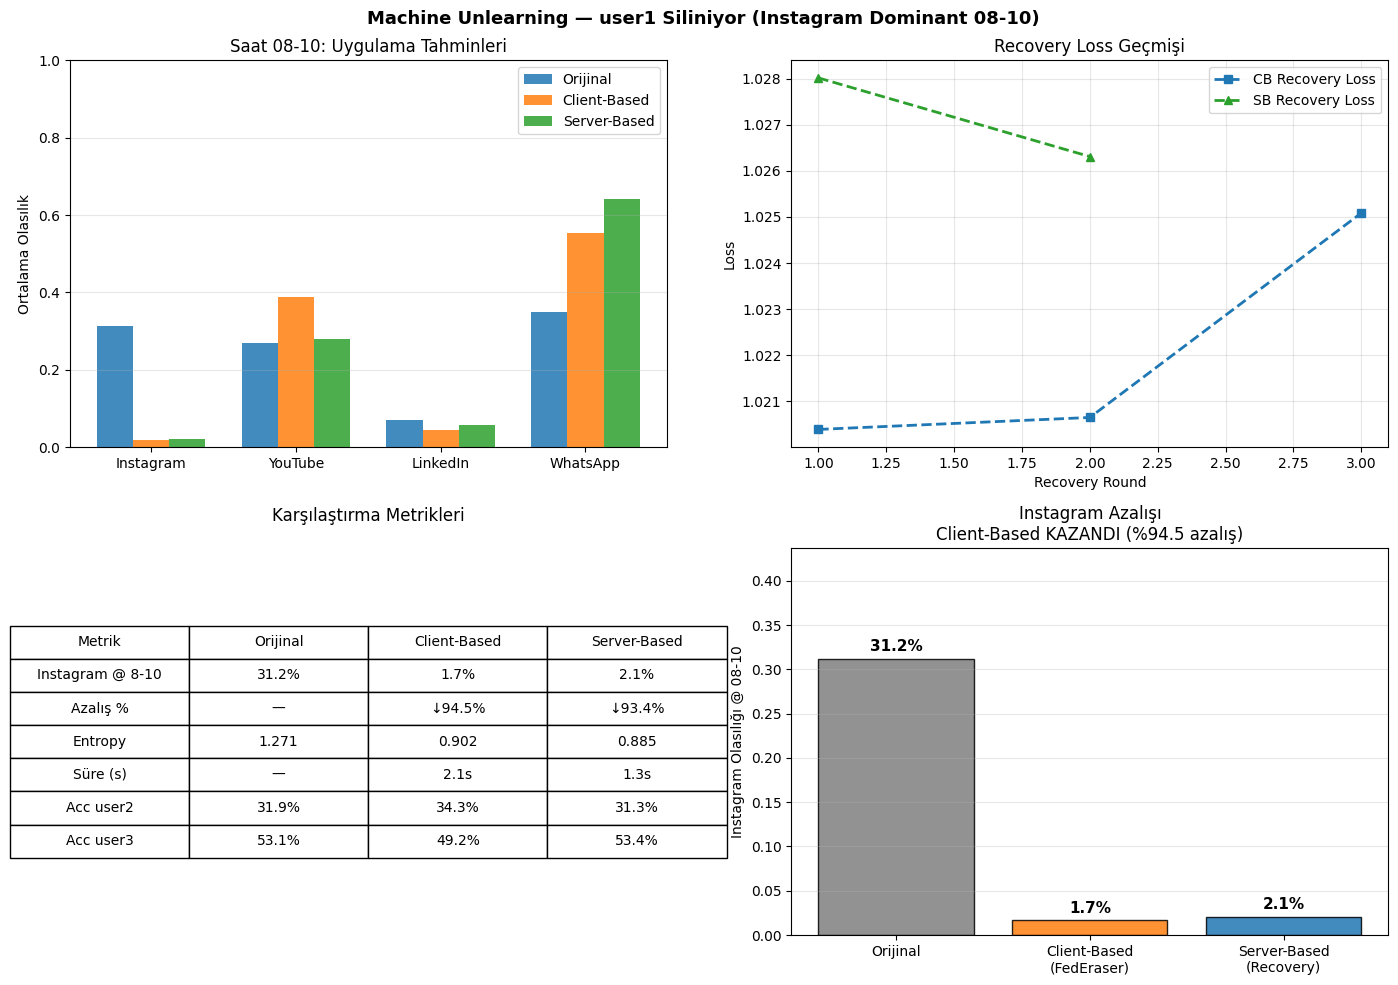

✅ Grafik kaydedildi: results/comparison_plot.png


In [13]:

# ============================================================
# AŞAMA 3: KARŞILAŞTIRMA VE ANALİZ
# ============================================================
print("=" * 60)
print("  AŞAMA 3: KARŞILAŞTIRMA VE ANALİZ")
print("=" * 60)

# Saat 8-10 tahminleri (gerçek verilerden)
orig_probs = analyze_8_to_10_predictions(global_model, FORGET_USER)
cb_probs   = analyze_8_to_10_predictions(cb_model,     FORGET_USER)
sb_probs   = analyze_8_to_10_predictions(sb_model,     FORGET_USER)

# Entropy
orig_entropy = calculate_entropy(orig_probs)
cb_entropy   = calculate_entropy(cb_probs)
sb_entropy   = calculate_entropy(sb_probs)

# Kalan client accuracy
remaining_acc = {}
for model_name, mdl in [("original", global_model), ("client_based", cb_model), ("server_based", sb_model)]:
    remaining_acc[model_name] = {u: calculate_accuracy(mdl, u) for u in REMAINING_USERS}

# Azalış %
orig_insta   = orig_probs["Instagram"]
cb_reduction = (orig_insta - cb_probs["Instagram"]) / orig_insta * 100
sb_reduction = (orig_insta - sb_probs["Instagram"]) / orig_insta * 100

# ── Console çıktısı ──────────────────────────────────────────
print(f"\nSaat 08-10 Instagram Olasılıkları ({orig_probs['sample_count']} veri noktası):")
print(f"  Orijinal    : {orig_insta:.1%}  (entropi: {orig_entropy:.3f})")
print(f"  Client-Based: {cb_probs['Instagram']:.1%}  (entropi: {cb_entropy:.3f})")
print(f"  Server-Based: {sb_probs['Instagram']:.1%}  (entropi: {sb_entropy:.3f})")

print(f"\nAzalış yüzdeleri (Instagram @ 8-10):")
arrow_cb = "↓" if cb_reduction > 0 else "↑"
arrow_sb = "↓" if sb_reduction > 0 else "↑"
print(f"  Client-Based: {arrow_cb} {abs(cb_reduction):.1f}%  {'✅' if cb_reduction > 0 else '❌'}")
print(f"  Server-Based: {arrow_sb} {abs(sb_reduction):.1f}%  {'✅' if sb_reduction > 0 else '❌'}")

print(f"\nClient-Based ek bilgi:")
print(f"  Correction norm (delta'nın büyüklüğü): {cb_results['correction_norm']:.4f}")
print(f"  Ort. round weight                    : {sum(cb_results['per_round_weights'])/len(cb_results['per_round_weights']):.3f}")

print(f"\nExecution Times:")
print(f"  Client-Based: {cb_results['total_time']:.2f}s")
sb_time_note = " (DAHA HIZLI)" if sb_results["total_time"] < cb_results["total_time"] else ""
print(f"  Server-Based: {sb_results['total_time']:.2f}s{sb_time_note}")

print(f"\nKalan Client Accuracy:")
for u in REMAINING_USERS:
    print(f"  {u}: Orig={remaining_acc['original'][u]:.1%} | CB={remaining_acc['client_based'][u]:.1%} | SB={remaining_acc['server_based'][u]:.1%}")

winner        = "Client-Based" if cb_reduction > sb_reduction else "Server-Based"
best_reduction = max(cb_reduction, sb_reduction)
print(f"\n{'='*60}")
print(f"  SONUÇ: {winner} Unlearning DAHA BAŞARILI")
print(f"  Instagram etkisini %{best_reduction:.1f} oranında sildi")
print(f"{'='*60}")

# ── JSON Raporu ───────────────────────────────────────────────
report = {
    "experiment_date": datetime.now().strftime("%Y-%m-%d"),
    "client_removed": FORGET_USER,
    "models": {
        "original": {**orig_probs, "entropy": orig_entropy},
        "client_based_unlearned": {
            **cb_probs, "entropy": cb_entropy,
            "reduction_percent": round(cb_reduction, 2),
            "execution_time_s": round(cb_results["total_time"], 2),
            "correction_norm": round(cb_results["correction_norm"], 4),
            "recovery_loss_history": cb_results["recovery_loss_history"]
        },
        "server_based_unlearned": {
            **sb_probs, "entropy": sb_entropy,
            "reduction_percent": round(sb_reduction, 2),
            "execution_time_s": round(sb_results["total_time"], 2),
            "recovery_loss_history": sb_results["recovery_loss_history"]
        }
    },
    "remaining_clients_accuracy": remaining_acc,
    "conclusion": f"{winner} Unlearning daha etkili (Instagram %{best_reduction:.1f} azaldı)"
}

with open("results/unlearning_results.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print("\n✅ JSON raporu kaydedildi: results/unlearning_results.json")

# ── Visualization ─────────────────────────────────────────────
apps        = ["Instagram", "YouTube", "LinkedIn", "WhatsApp"]
models_data = [("Orijinal", orig_probs), ("Client-Based", cb_probs), ("Server-Based", sb_probs)]
x     = np.arange(len(apps))
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Machine Unlearning — {FORGET_USER} Siliniyor (Instagram Dominant 08-10)",
             fontsize=13, fontweight="bold")

# Subplot 1: App probs at 8-10
ax1 = axes[0, 0]
for i, (label, probs) in enumerate(models_data):
    ax1.bar(x + i * width, [probs[a] for a in apps], width, label=label, alpha=0.85)
ax1.set_xticks(x + width)
ax1.set_xticklabels(apps)
ax1.set_ylabel("Ortalama Olasılık")
ax1.set_title("Saat 08-10: Uygulama Tahminleri")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Subplot 2: Recovery loss history
ax2 = axes[0, 1]
if cb_results["recovery_loss_history"]:
    ax2.plot(range(1, len(cb_results["recovery_loss_history"]) + 1),
             cb_results["recovery_loss_history"], "s--", color="tab:blue",
             label="CB Recovery Loss", linewidth=2, marker="s")
if sb_results["recovery_loss_history"]:
    ax2.plot(range(1, len(sb_results["recovery_loss_history"]) + 1),
             sb_results["recovery_loss_history"], "^--", color="tab:green",
             label="SB Recovery Loss", linewidth=2, marker="^")
ax2.set_xlabel("Recovery Round")
ax2.set_ylabel("Loss")
ax2.set_title("Recovery Loss Geçmişi")
ax2.legend()
ax2.grid(alpha=0.3)

# Subplot 3: Metrics table
ax3 = axes[1, 0]
ax3.axis("off")
table_rows = [
    ["Instagram @ 8-10", f"{orig_insta:.1%}",        f"{cb_probs['Instagram']:.1%}",       f"{sb_probs['Instagram']:.1%}"],
    ["Azalış %",         "—",                          f"{arrow_cb}{abs(cb_reduction):.1f}%", f"{arrow_sb}{abs(sb_reduction):.1f}%"],
    ["Entropy",          f"{orig_entropy:.3f}",        f"{cb_entropy:.3f}",                   f"{sb_entropy:.3f}"],
    ["Süre (s)",         "—",                          f"{cb_results['total_time']:.1f}s",    f"{sb_results['total_time']:.1f}s"],
]
for u in REMAINING_USERS:
    table_rows.append([
        f"Acc {u}",
        f"{remaining_acc['original'][u]:.1%}",
        f"{remaining_acc['client_based'][u]:.1%}",
        f"{remaining_acc['server_based'][u]:.1%}",
    ])
tbl = ax3.table(cellText=table_rows,
                colLabels=["Metrik", "Orijinal", "Client-Based", "Server-Based"],
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
ax3.set_title("Karşılaştırma Metrikleri", pad=20)

# Subplot 4: Instagram reduction bar
ax4 = axes[1, 1]
model_labels = ["Orijinal", "Client-Based\n(FedEraser)", "Server-Based\n(Recovery)"]
insta_vals   = [orig_insta, cb_probs["Instagram"], sb_probs["Instagram"]]
bar_clrs     = ["tab:gray", "tab:orange", "tab:blue"]
bars = ax4.bar(model_labels, insta_vals, color=bar_clrs, alpha=0.85, edgecolor="black")
ax4.set_ylabel("Instagram Olasılığı @ 08-10")
ax4.set_title(f"Instagram Azalışı\n{winner} KAZANDI (%{best_reduction:.1f} azalış)")
ax4.set_ylim(0, max(insta_vals) * 1.4)
for bar, val in zip(bars, insta_vals):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: results/comparison_plot.png")


## 12. SISA Unlearning — Karşılaştırma Referansı

**SISA (Sharded, Isolated, Sliced, and Aggregated)** unlearning'in temel fikri: unutulması istenen client hiç dahil edilmeden model sıfırdan eğitilir. Bu, teorik "mükemmel" unlearning sonucunu verir.

Bu hücrede Federated Learning **yalnızca user2 ve user3** ile baştan eğitiliyor:

| Parametre | Değer |
|-----------|-------|
| Clients | user2, user3 (user1 yok) |
| Round | 6 |
| Local epochs | 20 |
| Batch size | 32 |
| Learning rate | 0.01 |
| Aggregation | FedAvg |

Bu model "gerçek" unlearning baseline'ı olarak client-based ve server-based yöntemlerle karşılaştırılır.

In [14]:

# ============================================================
# SISA UNLEARNING — Sıfırdan Eğitim (user1 olmadan)
# ============================================================
print("=" * 60)
print("  SISA UNLEARNING: FL yalnızca user2 + user3 ile")
print("=" * 60)

SISA_USERS = ["user2", "user3"]

torch.manual_seed(SEED)
np.random.seed(SEED)

sisa_global_model = AppUsageModel().to(device)
sisa_global_state = sisa_global_model.state_dict()

sisa_round_history = []

for r in range(NUM_ROUNDS):
    print(f"\n  Round {r+1}/{NUM_ROUNDS}")
    client_states = []
    client_sizes  = []

    for user in SISA_USERS:
        window = user_windows[user][r]
        X, y   = window["X"], window["y"]
        state, acc, n = local_train(sisa_global_state, X, y,
                                    local_epochs=20, batch_size=32, lr=0.01)
        client_states.append(state)
        client_sizes.append(n)
        print(f"    {user}: {n} kayit | Local Acc: {acc*100:.1f}%")

    sisa_global_state = fed_avg(client_states, client_sizes)
    sisa_round_history.append({
        "round": r + 1,
        "state": copy.deepcopy(sisa_global_state)
    })

sisa_global_model.load_state_dict(sisa_global_state)
sisa_global_model.eval()

print(f"\n{'='*60}")
print("  SISA EĞİTİMİ TAMAMLANDI")
print(f"{'='*60}")

# 24 saat tahmin tablosu
sisa_results = predict_for_hours(sisa_global_model, range(24))
print()
print_predictions(sisa_results, title="  SISA Global Model — 24 Saat Tahmin Tablosu")


  SISA UNLEARNING: FL yalnızca user2 + user3 ile

  Round 1/6


    user2: 354 kayit | Local Acc: 43.8%


    user3: 371 kayit | Local Acc: 58.5%

  Round 2/6


    user2: 371 kayit | Local Acc: 43.9%


    user3: 352 kayit | Local Acc: 63.9%

  Round 3/6


...

    user2: 344 kayit | Local Acc: 44.2%
    user3: 365 kayit | Local Acc: 59.7%

  Round 5/6


    user2: 376 kayit | Local Acc: 47.1%


    user3: 365 kayit | Local Acc: 61.4%

  Round 6/6


    user2: 332 kayit | Local Acc: 49.1%


    user3: 361 kayit | Local Acc: 60.7%

  SISA EĞİTİMİ TAMAMLANDI

  SISA Global Model — 24 Saat Tahmin Tablosu
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 36.7%   36.7%  25.0%   3.7%  34.5%
 01:00   WhatsApp 38.1%   32.9%  21.7%   7.3%  38.1%
 02:00   WhatsApp 42.0%   20.0%  25.5%  12.5%  42.0%
 03:00   WhatsApp 41.3%   11.5%  30.0%  17.2%  41.3%
 04:00   WhatsApp 38.9%   10.4%  34.9%  15.8%  38.9%
 05:00    YouTube 43.2%   10.3%  43.2%  12.1%  34.4%
 06:00    YouTube 49.7%   10.6%  49.7%   7.5%  32.2%
 07:00   WhatsApp 43.0%   19.6%  31.9%   5.5%  43.0%
 08:00   WhatsApp 56.7%    9.9%  26.9%   6.5%  56.7%
 09:00   WhatsApp 64.8%    7.6%  20.2%   7.4%  64.8%
 10:00   WhatsApp 50.7%    8.3%   9.2%  31.8%  50.7%
 11:00   LinkedIn 45.8%   12.4%   3.4%  45.8%  38.4%
 12:00   LinkedIn 41.1%   36.4%   4.3%  41.1%  18.2%
 13:00  Instagram 51.4%   51.4%   4.7%  27.7%  16.2%
 14:00  Instagram 34.3%   34.3%  12.6%  27.8%  25.3%
 15:00   WhatsApp 37.6%   13.1%  18.1% 

  4 MODEL KARŞILAŞTIRMASI (8-10 Instagram)

  Model                 Insta@8-10    Azalis   Entropy    u2 Acc    u3 Acc
  ------------------------------------------------------------------------
  Orijinal                   31.2%         —     1.271     31.9%     53.1%
  Client-Based                1.7%    ↓94.5%     0.902     34.3%     49.2%
  Server-Based                2.1%    ↓93.4%     0.885     31.3%     53.4%
  SISA (Retrain)              8.4%    ↓73.0%     1.078     33.6%     49.0%

✅ JSON raporu guncellendi: results/unlearning_results.json


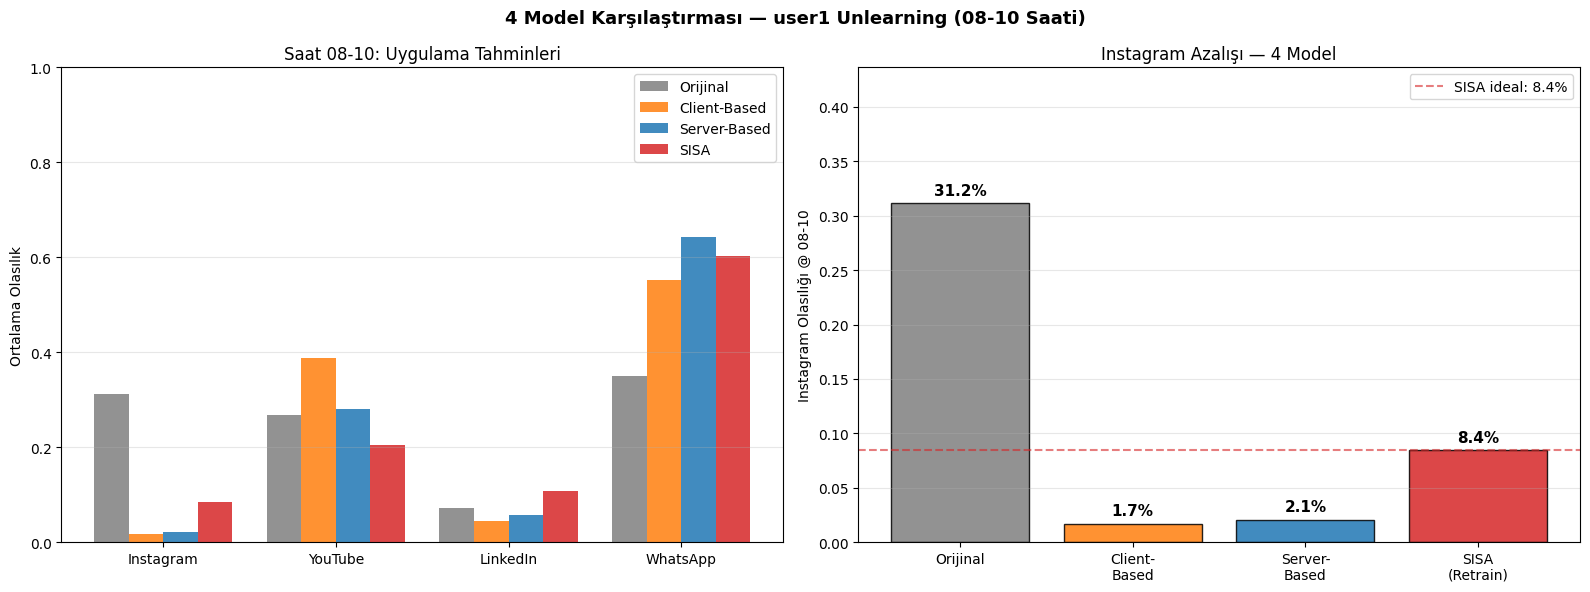

✅ Grafik kaydedildi: results/comparison_with_sisa.png


In [15]:

# ============================================================
# SISA + TÜM YÖNTEMLER KARŞILAŞTIRMASI
# ============================================================
print("=" * 60)
print("  4 MODEL KARŞILAŞTIRMASI (8-10 Instagram)")
print("=" * 60)

sisa_probs   = analyze_8_to_10_predictions(sisa_global_model, FORGET_USER)
sisa_entropy = calculate_entropy(sisa_probs)

sisa_acc = {u: calculate_accuracy(sisa_global_model, u) for u in REMAINING_USERS}

orig_insta  = orig_probs["Instagram"]
sisa_reduction = (orig_insta - sisa_probs["Instagram"]) / orig_insta * 100

print(f"\n  {'Model':20s}  {'Insta@8-10':>10}  {'Azalis':>8}  {'Entropy':>8}  {'u2 Acc':>8}  {'u3 Acc':>8}")
print("  " + "-" * 72)
for label, probs, entropy, red, acc_dict in [
    ("Orijinal",       orig_probs,  orig_entropy,  0,             remaining_acc["original"]),
    ("Client-Based",   cb_probs,    cb_entropy,    cb_reduction,  remaining_acc["client_based"]),
    ("Server-Based",   sb_probs,    sb_entropy,    sb_reduction,  remaining_acc["server_based"]),
    ("SISA (Retrain)", sisa_probs,  sisa_entropy,  sisa_reduction, sisa_acc),
]:
    arrow = "↓" if red > 0 else ("—" if red == 0 else "↑")
    red_str = f"{arrow}{abs(red):.1f}%" if red != 0 else "—"
    print(f"  {label:20s}  {probs['Instagram']:>10.1%}  {red_str:>8}  "
          f"{entropy:>8.3f}  {acc_dict['user2']:>8.1%}  {acc_dict['user3']:>8.1%}")

# JSON raporuna SISA ekle
with open("results/unlearning_results.json", "r", encoding="utf-8") as f:
    report = json.load(f)

report["models"]["sisa_retrain"] = {
    **sisa_probs,
    "entropy": sisa_entropy,
    "reduction_percent": round(sisa_reduction, 2),
    "note": "Sifirdan egitim — user1 hic dahil edilmedi (ideal baseline)"
}
report["remaining_clients_accuracy"]["sisa"] = {u: sisa_acc[u] for u in REMAINING_USERS}

with open("results/unlearning_results.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print("\n✅ JSON raporu guncellendi: results/unlearning_results.json")

# ── Karşılaştırma Grafiği ─────────────────────────────────────
apps = ["Instagram", "YouTube", "LinkedIn", "WhatsApp"]
all_models = [
    ("Orijinal",       orig_probs),
    ("Client-Based",   cb_probs),
    ("Server-Based",   sb_probs),
    ("SISA",           sisa_probs),
]
x     = np.arange(len(apps))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"4 Model Karşılaştırması — {FORGET_USER} Unlearning (08-10 Saati)",
             fontsize=13, fontweight="bold")

# Sol: Uygulama olasılıkları
ax1 = axes[0]
colors = ["tab:gray", "tab:orange", "tab:blue", "tab:red"]
for i, (label, probs) in enumerate(all_models):
    ax1.bar(x + i * width, [probs[a] for a in apps], width,
            label=label, color=colors[i], alpha=0.85)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(apps)
ax1.set_ylabel("Ortalama Olasılık")
ax1.set_title("Saat 08-10: Uygulama Tahminleri")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Sağ: Instagram azalış karşılaştırması
ax2 = axes[1]
model_labels  = ["Orijinal", "Client-\nBased", "Server-\nBased", "SISA\n(Retrain)"]
insta_vals    = [orig_probs["Instagram"], cb_probs["Instagram"],
                 sb_probs["Instagram"], sisa_probs["Instagram"]]
bar_colors    = ["tab:gray", "tab:orange", "tab:blue", "tab:red"]
bars = ax2.bar(model_labels, insta_vals, color=bar_colors, alpha=0.85, edgecolor="black")
ax2.set_ylabel("Instagram Olasılığı @ 08-10")
ax2.set_title("Instagram Azalışı — 4 Model")
ax2.set_ylim(0, max(insta_vals) * 1.4)
for bar, val in zip(bars, insta_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax2.axhline(y=sisa_probs["Instagram"], color="tab:red", linestyle="--",
            alpha=0.6, label=f"SISA ideal: {sisa_probs['Instagram']:.1%}")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/comparison_with_sisa.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: results/comparison_with_sisa.png")
